 
This notebook is use to optimize the Seq2Seq model on the complete data set.. 

In [53]:
import all_imports as ai

In [ ]:
data = ai.pd.read_csv("data")

In [ ]:
# ''' These are meant to update any changes made in any of these files to the notebook environment'''
# import importlib
# import revise_prepare
# importlib.reload(revise_prepare)

<module 'revise_prepare' from 'c:\\mythesis_work\\revise_prepare.py'>

In [54]:
from Seq2Se2_baseline import (SequenceToSequenceModel, ForecastPipeline)
from Seq2Seq_data_prep import (prepare_sequence_data, prepare_data)

In [16]:
df = prepare_data(data, "CO")

In [18]:
config = {
    "input_len": 24,          
    "output_len": 24,         
    "input_features": 18,    
    "target_features": 1,   
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_rate": 0.3,
    "target_index": 0,  
    "deco_input_features": 1,   
    "epochs": 1,           
}

In [19]:
(X_enc_train, X_dec_train, Y_train,
 X_enc_val, X_dec_val, Y_val,
 X_enc_test, X_dec_test, Y_test,
 scalers_test, target_column_name, output_seq_len) = prepare_sequence_data(df, input_seq_len=config["input_len"], output_seq_len=config["output_len"], target_indices=[0], split_ratio=(0.7, 0.85))

287/287 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 1.0583 - mae: 0.7778 - val_loss: 0.4380 - val_mae: 0.4955

📊 Evaluation on Inverse-Transformed Test Set:
MAE   = 20.5195
MAPE  = 10.8211%
SMAPE = 10.2157%
MSE   = 964.8196
RMSE  = 31.0615
Sparsity_level: Baseline_48_FH


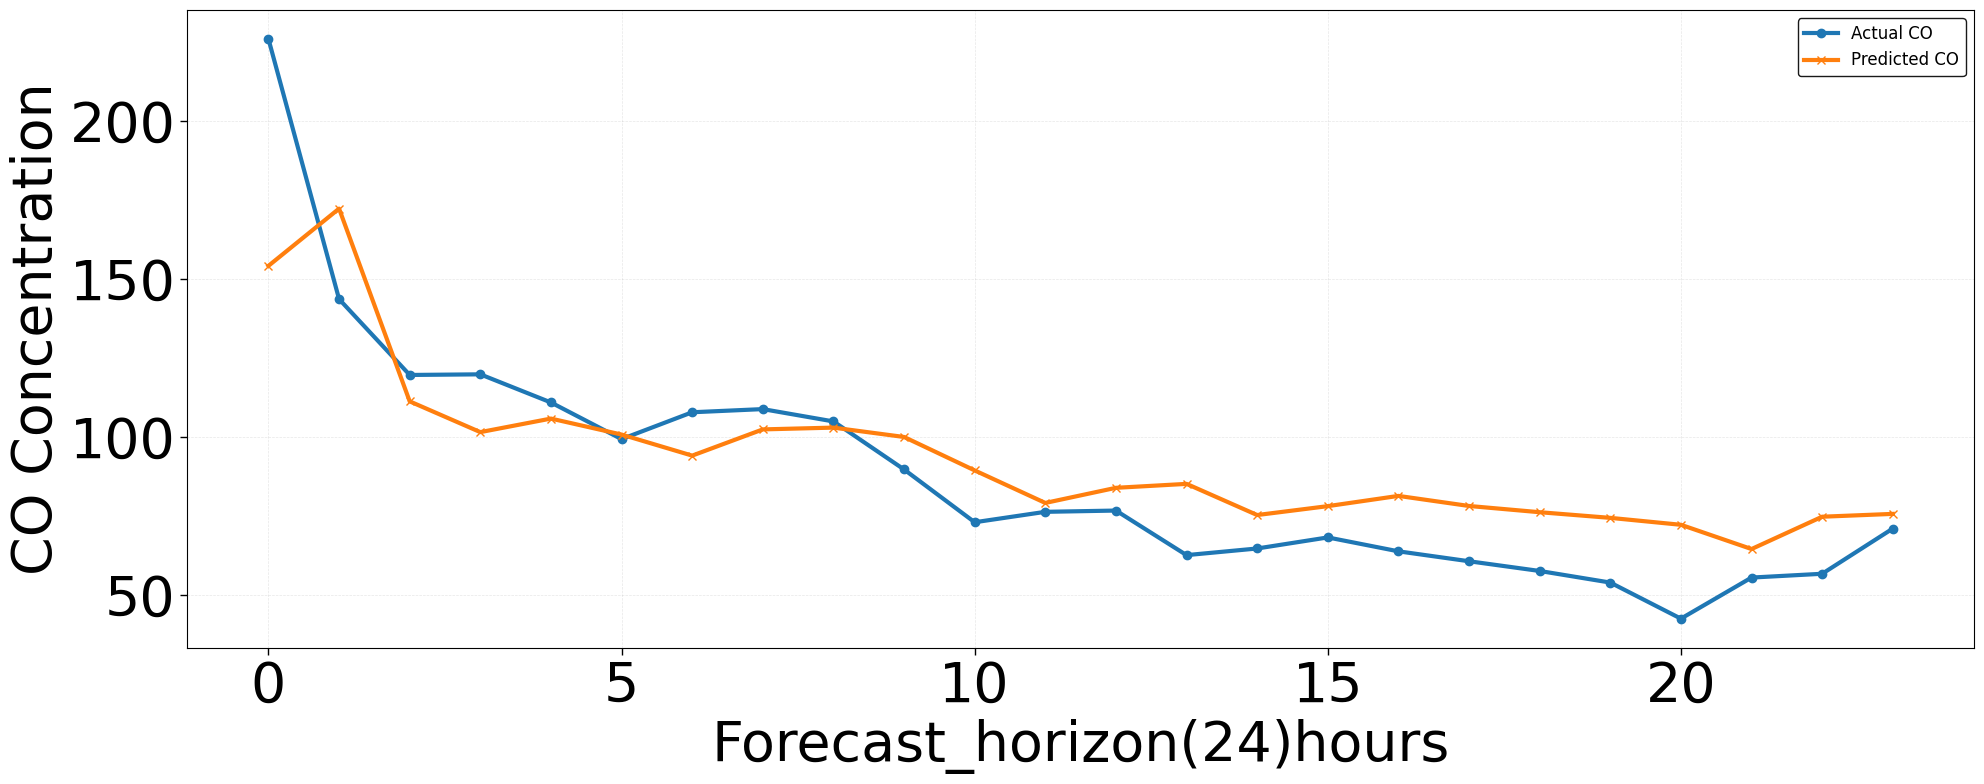

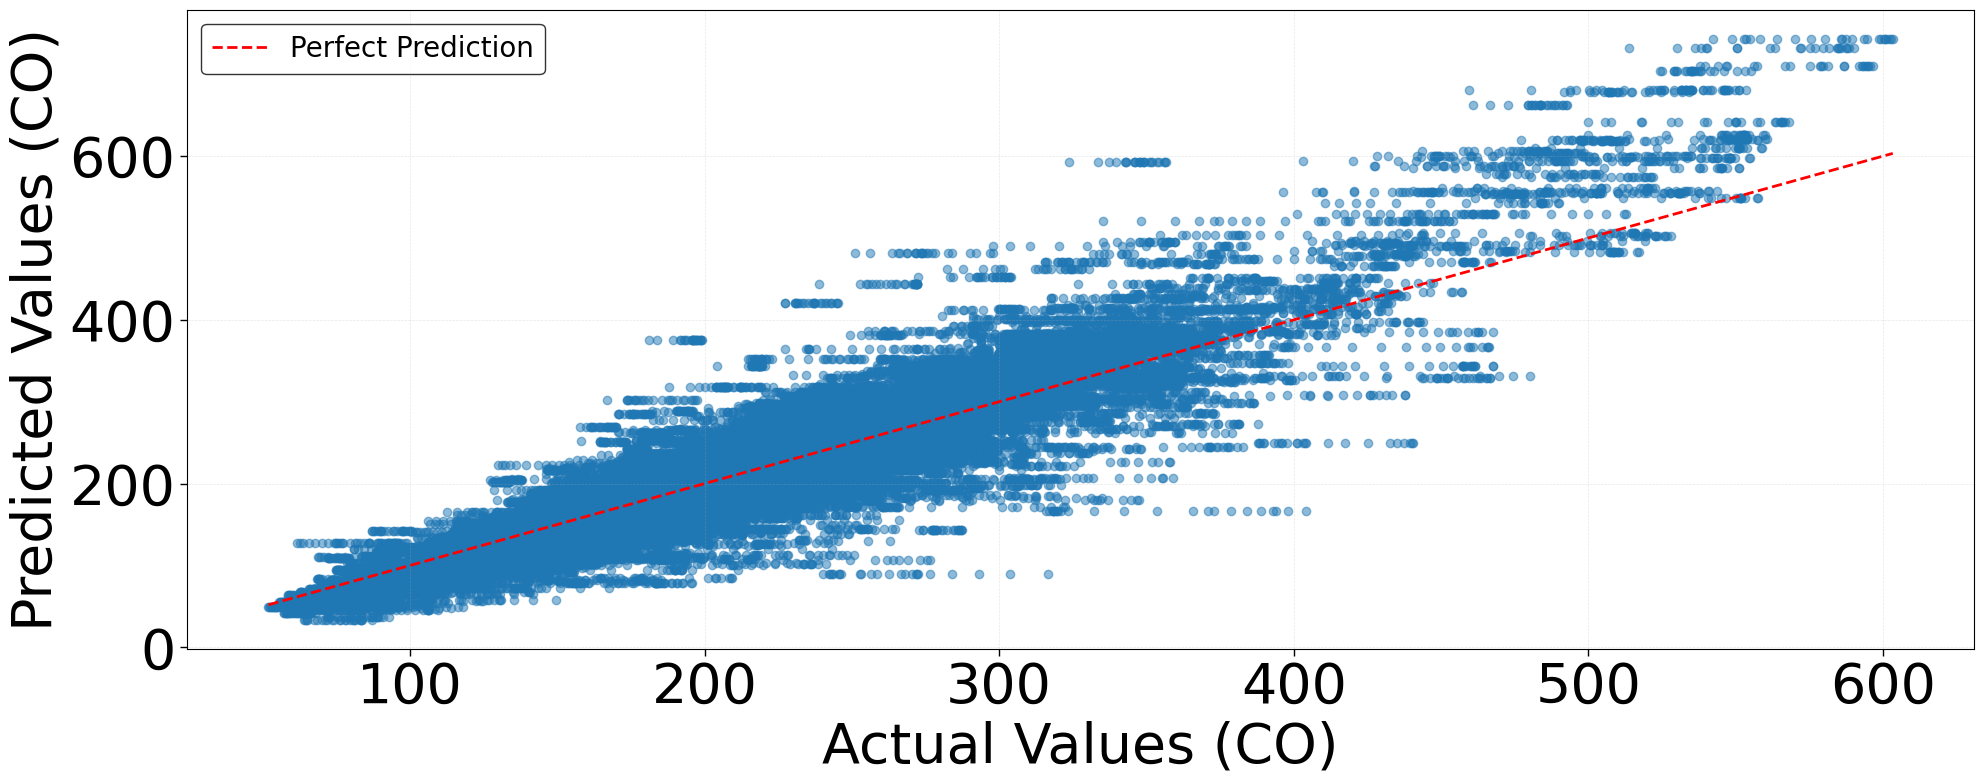

In [20]:
'''Run a simple pipeline to see if the model works..'''


model = SequenceToSequenceModel(enc_units=64, dec_units=64, output_dim=1, dropout_rate=0.3)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

pipeline = ForecastPipeline(model, sparsity_level="Baseline_48_FH", scaler_list=scalers_test)

# Traindsfjdsjsadkd

history = pipeline.train_model(X_enc_train, X_dec_train, Y_train,
                             X_enc_val, X_dec_val, Y_val,
                               batch_size=64, epochs=1, patience=5)

# Evaluate
Y_true, Y_pred = pipeline.evaluate_model(X_enc_test, X_dec_test, Y_test)

# Metrics
metrices = pipeline.compute_metrics(Y_true, Y_pred, target_column_name)
#save_path= f"results_plot/forecasting_baseline_{target_column_name}_{output_seq_len}
# Plot
pipeline.plot_forecast(Y_true, Y_pred, target_column_name, output_seq_len)
#save_path= f"results_plot/error_ditsri_baseline_{target_column_name}_{output_seq_len}",
pipeline.plot_error_distribution(Y_pred, Y_true, target_column_name,  show_histogram=False)

# Full optimization pipeline with Optuna

In [118]:
config = {
    "input_len": 24,          
    "output_len": 48,         
    "input_features": 18,    
    "target_features": 1,   
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_rate": 0.3,
    "target_index": 0,  
    "deco_input_features": 1,   
    "epochs": 1,           
}

In [21]:
def objective(trial):
    # 📊 Sample hyperparameters
    config = {"enc_units": trial.suggest_int("enc_units", 32, 128),
              "dec_units" :trial.suggest_int("dec_units", 32, 128),
              "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
              "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
              "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
              "epochs": trial.suggest_int("epochs", 1, 2)}
   

    # 🧠 Build model
    model = SequenceToSequenceModel(
        enc_units=config["enc_units"],
        dec_units=config["dec_units"],
        output_dim=1,
        dropout_rate=config["dropout_rate"]
    )
    model.compile(optimizer=ai.tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
                  loss='mse', metrics=['mae'])

    # 🔁 Train
    pipeline = ForecastPipeline(model, scaler_list=scalers_test)
    history = pipeline.train_model(
        X_enc_train, X_dec_train, Y_train,
        X_enc_val, X_dec_val, Y_val,
        batch_size=config["batch_size"],
        epochs=config["epochs"],
        patience=5
    )

    # 📉 Evaluate on validation set
    val_loss = min(history.history['val_mae'])  # or 'val_loss' if preferred

    return val_loss

In [42]:
def test_and_extract():



    study_baseline = ai.optuna.create_study(direction="minimize")
    study_baseline.optimize(objective, n_trials=1)

  
    best_params = study_baseline.best_trial.params
    best_params_baseline = study_baseline.best_trial.params
    print("Best MAE:", study_baseline.best_trial.value)
    print("Best hyperparameters:", best_params_baseline)


    best_config = { "best_enc_units": best_params["enc_units"],
               "best_dec_units": best_params["dec_units"],
               "best_dropout": best_params["dropout_rate"],
               "best_lr": best_params["learning_rate"],
               "best_epoch": best_params["epochs"], 
               "best_batch_size": best_params["batch_size"]}
    
    model = SequenceToSequenceModel(
        enc_units=best_config["best_enc_units"],
        dec_units=best_config["best_dec_units"],
        output_dim=1,
        dropout_rate=best_config["best_dropout"])

    model.compile(
        optimizer=ai.tf.keras.optimizers.Adam(learning_rate=best_config["best_lr"]),
        loss='mse',
        metrics=['mae'])
    
    pipeline = ForecastPipeline(model, sparsity_level="baseline_48_24_FH", scaler_list=scalers_test)

    history = pipeline.train_model(
        X_enc_train, X_dec_train, Y_train,
        X_enc_val, X_dec_val, Y_val,
        batch_size=best_config["best_batch_size"],
        epochs=best_config["best_epoch"],
        patience=5
        )
    
    return model,  best_params_baseline

In [43]:
model, best_params_baseline = test_and_extract()

[I 2025-11-20 12:07:20,993] A new study created in memory with name: no-name-2a50bc76-0973-44fc-8e2e-bcb51cbcb29a


Epoch 1/2
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - loss: 2.1711 - mae: 1.1549 - val_loss: 0.6110 - val_mae: 0.6106
Epoch 2/2
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 1.5008 - mae: 0.9611 - val_loss: 0.4989 - val_mae: 0.5342


[I 2025-11-20 12:07:54,942] Trial 0 finished with value: 0.534156084060669 and parameters: {'enc_units': 45, 'dec_units': 107, 'dropout_rate': 0.38710249930846496, 'learning_rate': 0.00017512137850625212, 'batch_size': 128, 'epochs': 2}. Best is trial 0 with value: 0.534156084060669.


Best MAE: 0.534156084060669
Best hyperparameters: {'enc_units': 45, 'dec_units': 107, 'dropout_rate': 0.38710249930846496, 'learning_rate': 0.00017512137850625212, 'batch_size': 128, 'epochs': 2}
Epoch 1/2
144/144 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - loss: 2.0268 - mae: 1.1205 - val_loss: 0.6575 - val_mae: 0.6351
Epoch 2/2
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 1.4397 - mae: 0.9420 - val_loss: 0.5214 - val_mae: 0.5451



📊 Evaluation on Inverse-Transformed Test Set:
MAE   = 23.0496
MAPE  = 11.9409%
SMAPE = 11.3303%
MSE   = 1245.8911
RMSE  = 35.2972
Sparsity_level: baseline_48_FH


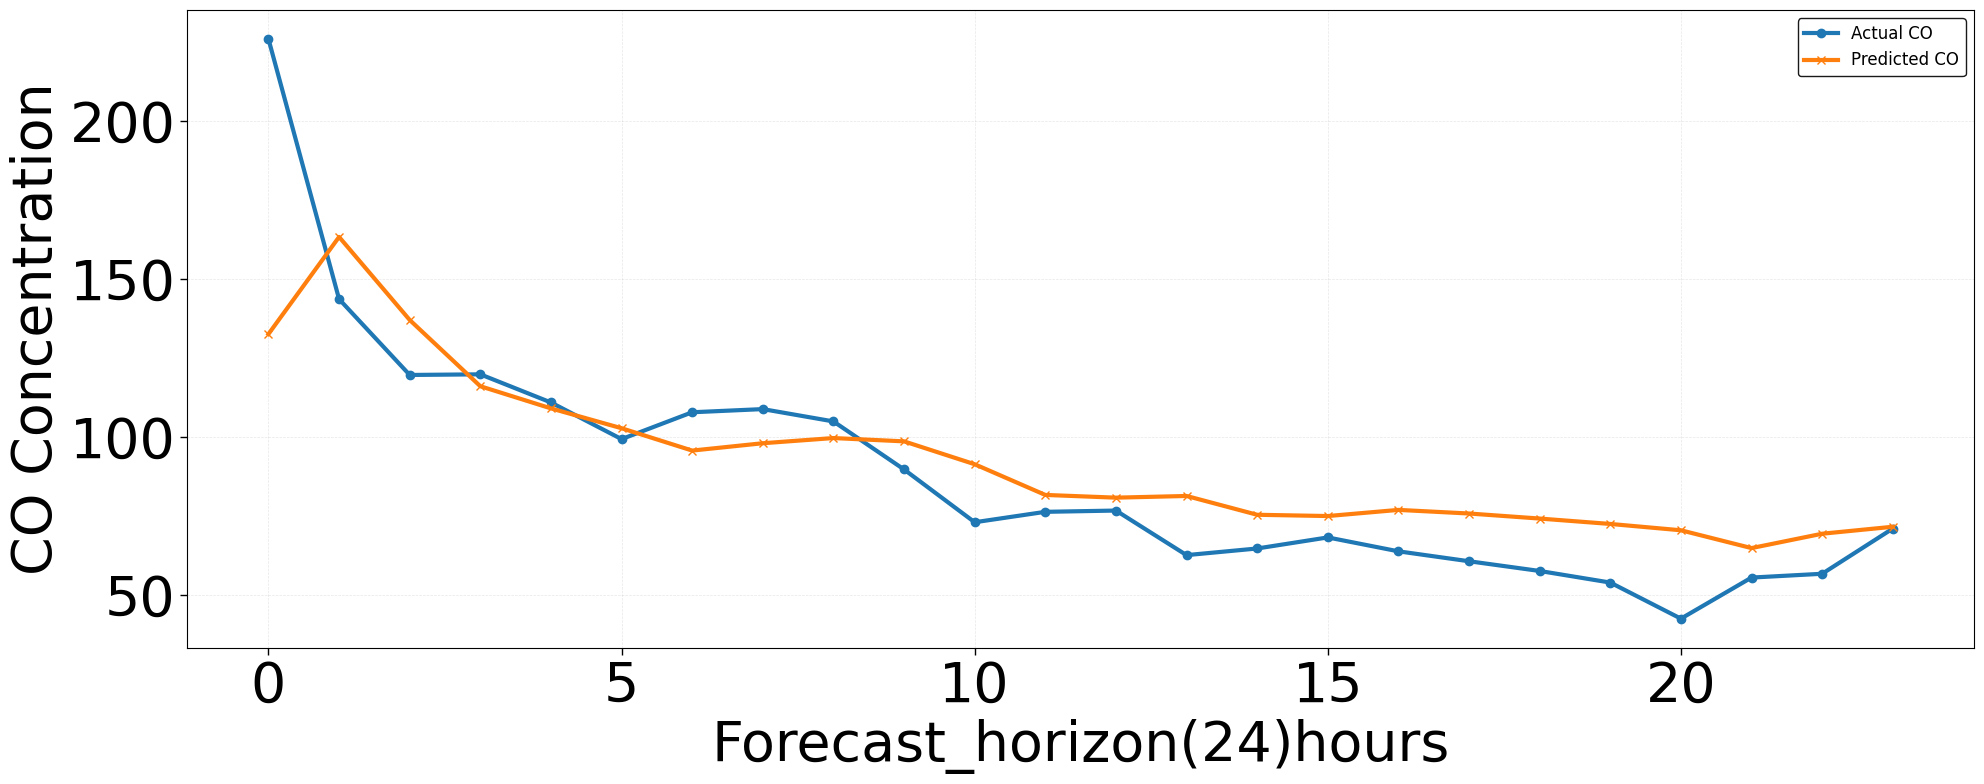

c:\mythesis_work\revise_baseline.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=20, loc='upper left', frameon=True, framealpha=0.8)


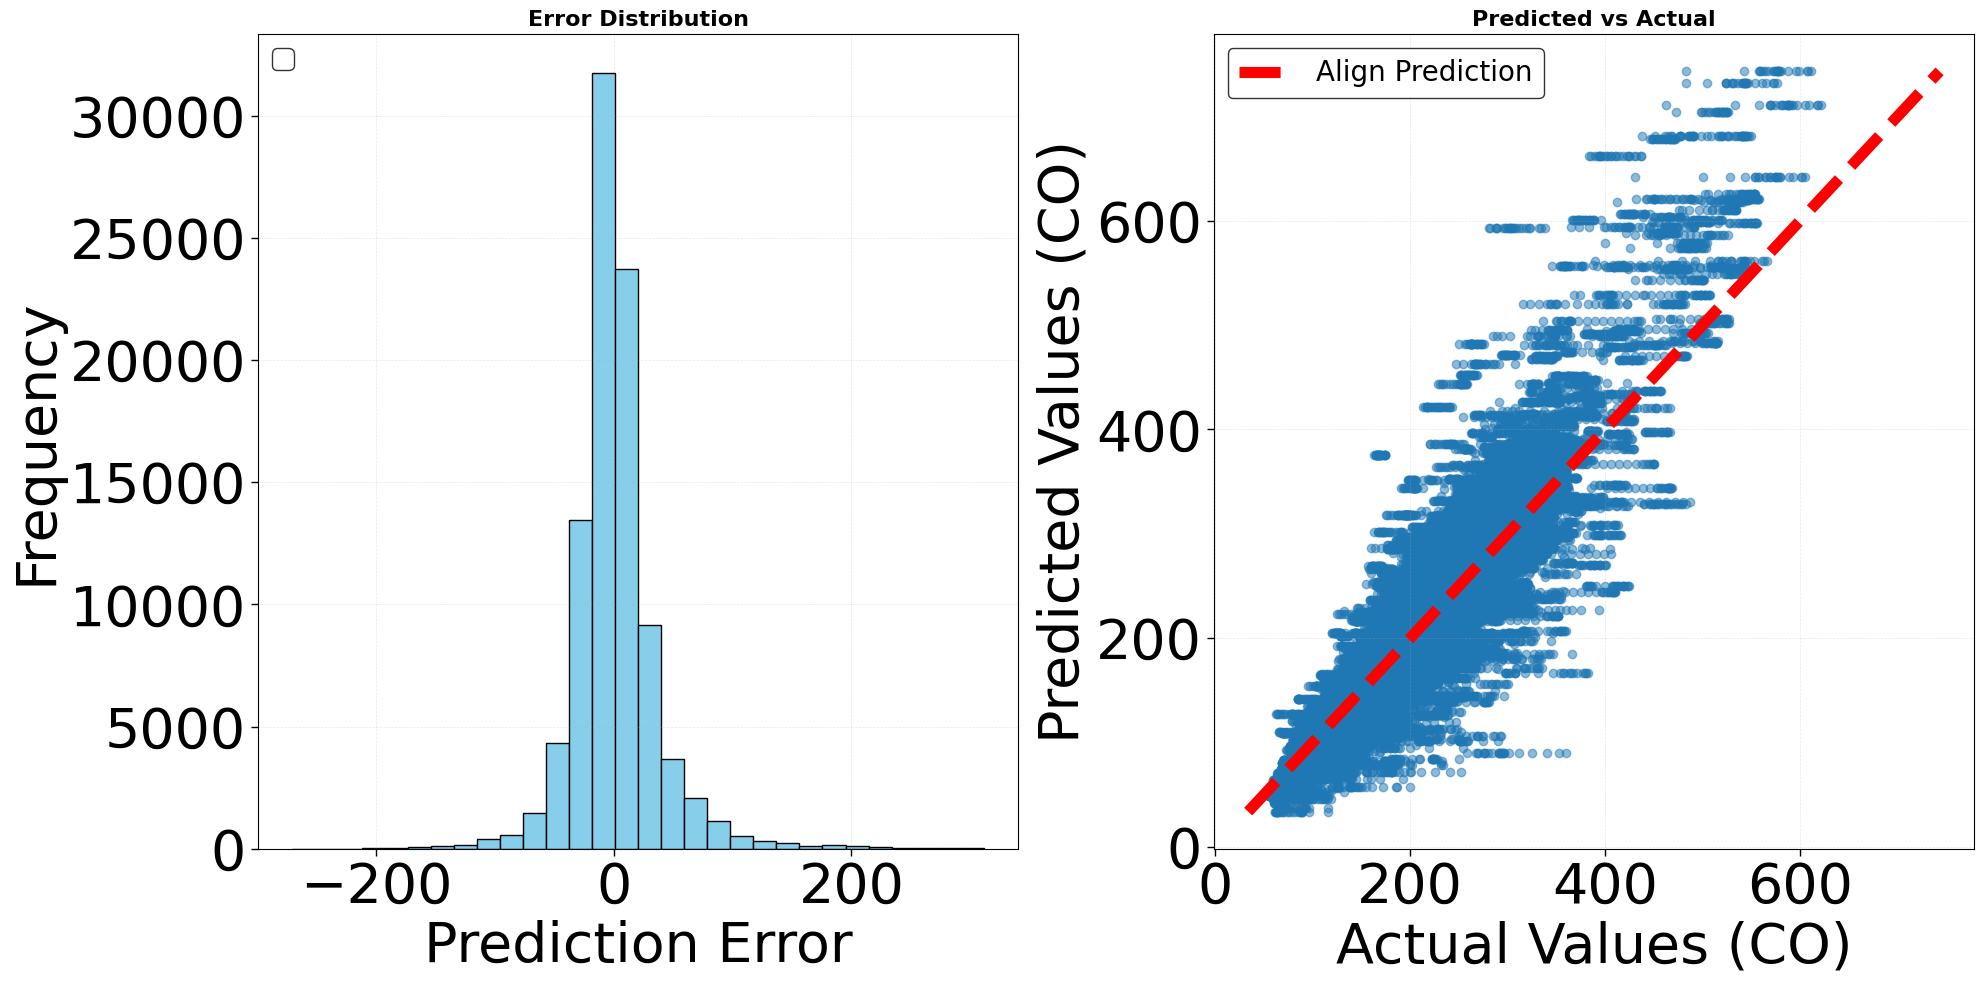

In [ ]:

pipeline_baseline = ForecastPipeline(model, sparsity_level="baseline_48_FH", scaler_list=scalers_test)
Y_true, Y_pred = pipeline_baseline.evaluate_model(X_enc_test, X_dec_test, Y_test)
# pipeline.compute_metrics(Y_true, Y_pred)
# pipeline.plot_forecast(Y_true, Y_pred, target_column_name)
# pipeline.plot_error_distribution(Y_true, Y_pred, target_column_name, show_histogram=False)
# Metrics
metrices_baseline = pipeline_baseline.compute_metrics(Y_true, Y_pred, target_column_name)

# Plot
# save_path= f"results_plot/forecasting_baseline_{target_column_name}_{output_seq_len}"
pipeline_baseline.plot_forecast(Y_true, Y_pred, target_column_name, output_seq_len)

pipeline_baseline.plot_error_distribution(Y_pred, Y_true, target_column_name)
# #save_path= f"results_plot/error_ditsri_baseline_{target_column_name}_{output_seq_len}"
# pipeline_baseline.plot_training_history(history, highlight_best=True, smooth=True)pipeline_baseline = ForecastPipeline(model, sparsity_level="baseline_48_FH", scaler_list=scalers_test)


''' The code in Seq2Seq_baseline.py will show all the paramters.. mainly for plotting and saving figures'''

In [127]:
metrices_baseline


{'MAE': 3.2019,
 'MAPE %': 21.4222,
 'SMAPE %': 19.0123,
 'RMSE': 4.3205,
 'Sparsity_Type': 'baseline_48_FH',
 'Polluntant_name': 'PMI-10'}

In [45]:
combined_baseline = {**metrices_baseline, **best_params_baseline} # Merge both dictionaries
# results_baseline = ai.pd.DataFrame.from_dict(combined_baseline, orient="index").T 
# results_baseline.to_csv("baseline.csv", index=False)

In [46]:
metrices_baseline

{'MAE': 23.0496,
 'MAPE %': 11.9409,
 'SMAPE %': 11.3303,
 'RMSE': 35.2972,
 'Sparsity_Type': 'baseline_48_FH',
 'Polluntant_name': 'CO'}

In [47]:
baseline = ai.pd.DataFrame.from_dict(combined_baseline, orient="index").T
baseline.to_csv("baseline.csv", mode="a", header=False, index=False)

In [48]:
baseline = ai.pd.read_csv("baseline.csv")


In [51]:
baseline = ai.pd.read_csv("baseline.csv")